In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt

from crc.config import get_settings
from crc.datagen.calendar import build_calendar
from crc.datagen.demand import generate_demand
from crc.datagen.events import generate_events
from crc.datagen.params import GeneratorParams
from crc.datagen.rng import make_rngs

s = get_settings()
cal = build_calendar(s.history_start_date, s.history_end_date, s.time_granularity_minutes)
p = GeneratorParams()
rngs = make_rngs(s.random_seed)
end = cal["ts"].iloc[-1] + pd.Timedelta(minutes=s.time_granularity_minutes)
events = generate_events(cal["ts"].iloc[0], end, p.events, rngs["events"])
d = generate_demand(cal, events, p.demand, rngs).set_index("ts")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


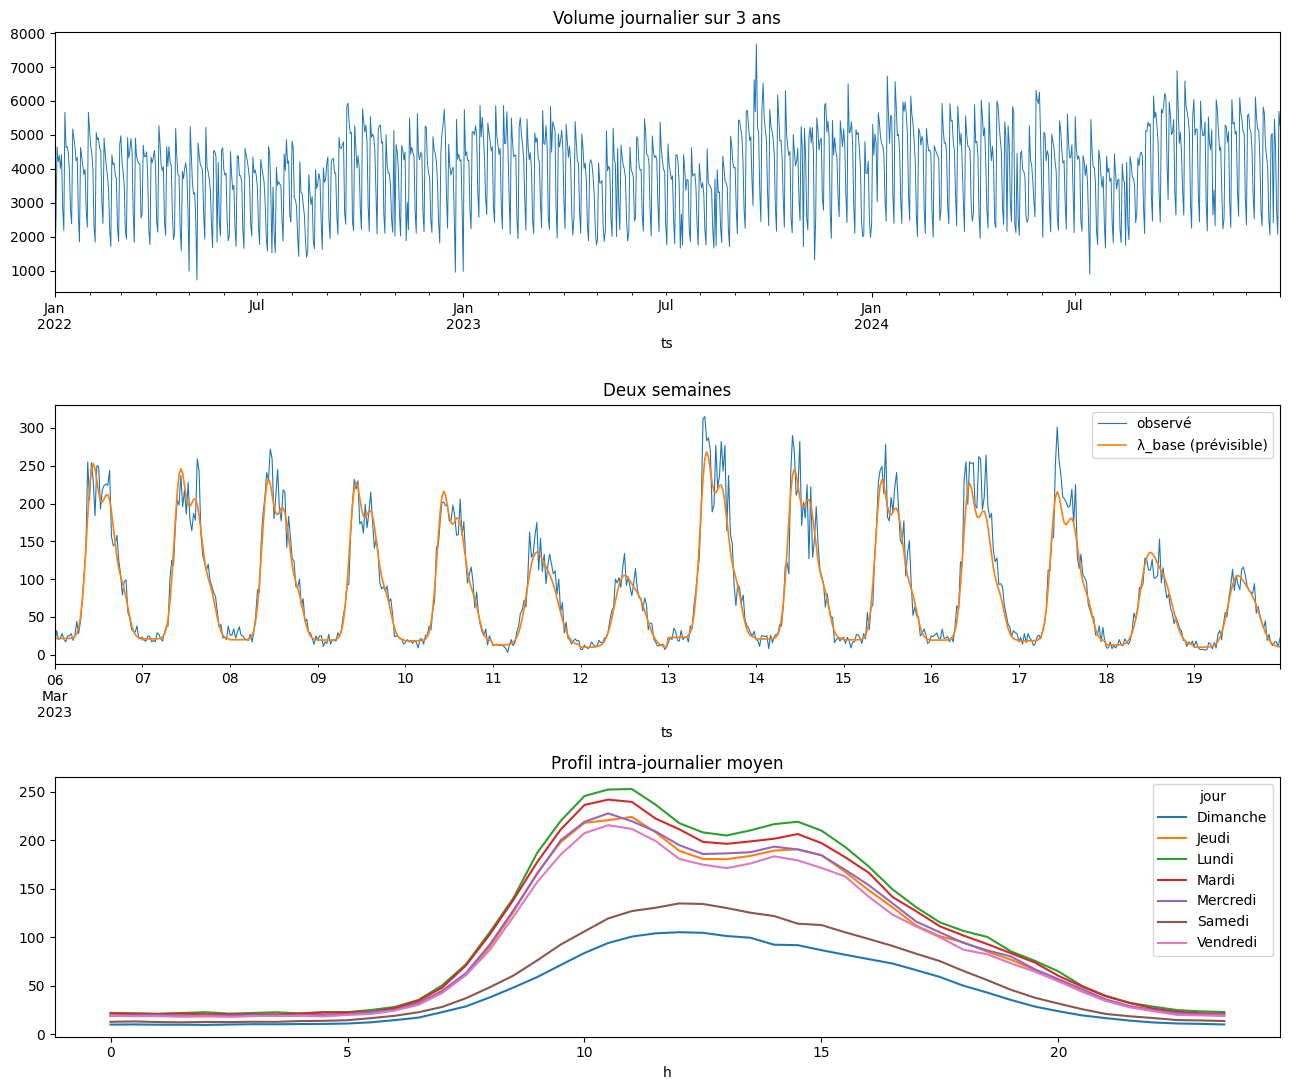

In [3]:
fig, ax = plt.subplots(3, 1, figsize=(13, 11))

d["offered"].resample("D").sum().plot(ax=ax[0], lw=0.7)
ax[0].set_title("Volume journalier sur 3 ans")

w = d.loc["2023-03-06":"2023-03-19"]
w["offered"].plot(ax=ax[1], lw=0.8, label="observé")
w["lambda_base"].plot(ax=ax[1], lw=1.2, label="λ_base (prévisible)")
ax[1].legend(); ax[1].set_title("Deux semaines")

c = cal.set_index("ts")
d.assign(h=c["hour"] + c["minute"] / 60, jour=c["day_name"]) \
 .pivot_table(index="h", columns="jour", values="offered").plot(ax=ax[2])
ax[2].set_title("Profil intra-journalier moyen")

plt.tight_layout()